# 05 — Physics-Informed Neural Networks on Curved Surfaces

Every PDE in this series so far has lived on a flat domain: an interval $[0,1]$, or a flat 2-D patch. Most PDEs that matter in geometry processing, graphics and physical simulation live on **curved surfaces** instead (a sphere, a shell a scanned mesh). This notebook builds, from first principles, the minimal set of ideas needed to point a PINN at a curved surface instead of a flat box, following:

> P. Jain, N. Kairanda, P. Y. Chen, O. Stein. **PINNsur: Physics-Informed Neural Networks for PDEs on Curved Surfaces.** Preprint, 2026. [arXiv:2605.27308](https://arxiv.org/abs/2605.27308).

## 0. Background: the differential geometry you need, and nothing more

### Surface

A **surface** $\Omega \subseteq \mathbb{R}^3$ (also called a 2-manifold embedded in $\mathbb{R}^3$) is a set that locally looks like a bent piece of the plane: around every point, a small enough patch of $\Omega$ can be smoothly flattened without tearing or folding. Spheres, cylinders, tori, and triangle meshes that approximate any of these are all surfaces in this sense.

### Tangent plane and normal vector

At a point $\mathbf{x}\in\Omega$, the **tangent plane** $T_\mathbf{x}\Omega$ is the 2-dimensional plane of directions you can move in while staying on the surface to first order — think of a coin balanced flat against the surface at $\mathbf{x}$. The **normal vector** $\mathbf{n}(\mathbf{x})$ is the unit vector perpendicular to $T_\mathbf{x}\Omega$. A surface is **orientable** if a smooth, globally consistent choice of $\mathbf{n}$ exists across the whole surface (true for every example in this notebook, and true for essentially every surface that shows up in practice). This normal field is the *only* piece of geometric information the method below needs (no mesh, no parameterization, no reference domain).

### Why the ordinary gradient is not enough

Let $u:\mathbb{R}^3\to\mathbb{R}$ be a coordinate network. Autodiff hands you its Euclidean gradient $\nabla u\in\mathbb{R}^3$ for free. The problem: $\nabla u$ generally does **not** lie in the tangent plane $T_\mathbf{x}\Omega$. Part of it points along $\mathbf{n}(\mathbf{x})$, i.e. *off* the surface, in a direction nothing confined to $\Omega$ could ever move in. If $u$ is only meant to describe something living on $\Omega$ (a temperature field on a shell, say), that off-surface component is not physical — it is an artifact of having extended $u$ to the ambient space $\mathbb{R}^3$ so that autodiff has something to differentiate.

### Surface (tangential) gradient

$$
\nabla_\Omega u \;:=\; \nabla u - (\nabla u\cdot\mathbf{n})\,\mathbf{n}.
$$

**How:** one dot product and one subtraction, once you already have $\nabla u$ and $\mathbf n$.
**Why:** this is the unique vector lying in $T_\mathbf{x}\Omega$ that reproduces the directional derivative of $u$ along every tangential direction. It is the correct notion of "gradient" for a function that only really lives on $\Omega$.

### Surface divergence

For a vector field $\mathbf{F}:\mathbb{R}^3\to\mathbb{R}^3$,

$$
\nabla_\Omega\cdot\mathbf{F} \;:=\; \nabla\cdot\mathbf{F} - \mathbf{n}^\top J(\mathbf{F})\,\mathbf{n},
\qquad
J(\mathbf{F})_{ij} = \frac{\partial F_i}{\partial x_j}.
$$

**How:** $J(\mathbf F)$ is the full $3\times3$ Jacobian of the vector field — it needs *one autodiff call per output component* of $\mathbf F$, not one call total. This is the one new mechanical skill in this notebook (Section 2).
**Why:** exactly the same idea as the gradient projection; $\mathbf{n}^\top J(\mathbf F)\mathbf n$ is the part of the divergence that measures change *along the normal*, which is not a statement about the surface.

### Laplace–Beltrami operator (the surface Laplacian)

$$
\Delta_\Omega u \;:=\; \nabla_\Omega\cdot(\nabla_\Omega u).
$$

The surface divergence of the surface gradient (the direct curved-surface generalization of the flat Laplacian). **Why this particular combination:** it is the operator that correctly describes diffusion, heat flow and steady sourced-equilibrium problems (Poisson-type) that are physically confined to a curved surface.

### The PDE problem

$$
\Delta_\Omega u = f \quad \text{on } \Omega
\qquad\text{(Poisson equation)},
\qquad\qquad
u = g \quad \text{on } \partial\Omega_D
\qquad\text{(Dirichlet boundary)}.
$$

Some surfaces have no boundary at all (a full sphere, $\partial\Omega=\varnothing$); others, like a finite cylinder, have one. 

### PINN framing

The recipe is the same shape as every notebook so far: represent $u$ by a coordinate network $u_\theta:\mathbb{R}^3\to\mathbb{R}$, sample collocation points $\mathbf{x}_i$ **on $\Omega$** (never off it — the network is only ever evaluated at points that lie on the surface), and minimize

$$
\mathcal{L} = \frac{1}{N}\sum_i \big(\Delta_\Omega u_\theta(\mathbf{x}_i) - f(\mathbf{x}_i)\big)^2
\;+\; \lambda_{BC}\,\mathcal{L}_{BC} \ \text{(if } \partial\Omega\neq\varnothing\text{)}.
$$

What is genuinely new is *only* how $\Delta_\Omega$ is computed; everything about sampling, training loops, and loss weighting carries over unchanged.


## 1. Setup

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)

## 2. From one derivative to a Jacobian

The surface divergence needs the *full* $3\times3$ Jacobian of a vector-valued field $\mathbf F:\mathbb{R}^3\to\mathbb{R}^3$; one such row **per output component** of $\mathbf F$.

**How:** loop over the 3 output components of $\mathbf F$, call `torch.autograd.grad` once per component (each call differentiates one scalar output with respect to all 3 input coordinates), and stack the resulting rows into an $(N,3,3)$ tensor, where row $i$ is $\nabla F_i$.

Implement `vector_jacobian` below, and check it against a vector field whose Jacobian you can write down by hand.

In [2]:
def vector_jacobian(vector_fn, x: torch.Tensor) -> torch.Tensor: # full jacobian of vector_fn
    F = vector_fn(x)
    rows = []
    for i in range(F.shape[1]):
        row_i = torch.autograd.grad(
            outputs=F[:, i], inputs=x,
            grad_outputs=torch.ones_like(F[:, i]),
            create_graph=True,
        )[0]
        rows.append(row_i)
    return torch.stack(rows, dim=1)


# Sanity check: F(x) = (x0^2, x0*x1, x2) has the closed-form Jacobian
#   [[2*x0,   0,    0],
#    [  x1,  x0,    0],
#    [   0,   0,    1]]
def _F_test(x):
    return torch.stack([x[:, 0] ** 2, x[:, 0] * x[:, 1], x[:, 2]], dim=1)

x_test = torch.tensor([[2.0, 3.0, 5.0]], requires_grad=True)
J_test = vector_jacobian(_F_test, x_test)
J_expected = torch.tensor([[[4.0, 0.0, 0.0], [3.0, 2.0, 0.0], [0.0, 0.0, 1.0]]])
print("computed Jacobian:\n", J_test.detach())
print("max |error|:", (J_test.detach() - J_expected).abs().max().item())

computed Jacobian:
 tensor([[[4., 0., 0.],
         [3., 2., 0.],
         [0., 0., 1.]]])
max |error|: 0.0


## 3. Surface gradient and the Laplace–Beltrami operator

Translate Section 0's two formulas directly into code:

$$
\nabla_\Omega u = \nabla u - (\nabla u\cdot\mathbf n)\,\mathbf n,
\qquad\qquad
\Delta_\Omega u = \operatorname{tr}\!\big(J(\nabla_\Omega u)\big) - \mathbf n^\top J(\nabla_\Omega u)\,\mathbf n.
$$

(The surface divergence of a field $\mathbf F$ is $\operatorname{tr}(J(\mathbf F)) - \mathbf n^\top J(\mathbf F)\mathbf n$, and here $\mathbf F=\nabla_\Omega u$; $\operatorname{tr}(J(\mathbf F))=\nabla\cdot\mathbf F$ since the trace of a Jacobian is exactly the ordinary Euclidean divergence.)

In [3]:
def surface_gradient(model, x: torch.Tensor, normal_fn) -> torch.Tensor: # tangential gradient of model(x) at each point x
    u = model(x)
    grad_u = torch.autograd.grad(
        outputs=u, inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]
    n = normal_fn(x)
    return grad_u - (grad_u * n).sum(dim=1, keepdim=True) * n

def laplace_beltrami(model, x: torch.Tensor, normal_fn) -> torch.Tensor: # laplace-beltrami operator applied to model at each x
    def tangential_field(x_):
        return surface_gradient(model, x_, normal_fn)
    J = vector_jacobian(tangential_field, x)
    n = normal_fn(x)
    divergence = J[:, 0, 0] + J[:, 1, 1] + J[:, 2, 2]
    quadratic_form = torch.einsum("bi,bij,bj->b", n, J, n)
    return (divergence - quadratic_form).unsqueeze(1)

def normal_sphere(x: torch.Tensor) -> torch.Tensor:
    return x / x.norm(dim=1, keepdim=True)

class _IdentityZ: # just returns z-coord; no net, no training, any error is purely in operator
    def __call__(self, x):
        return x[:, 2:3]

x_sphere_test = torch.randn(6, 3)
x_sphere_test = (x_sphere_test / x_sphere_test.norm(dim=1, keepdim=True)).requires_grad_(True)

lb_test = laplace_beltrami(_IdentityZ(), x_sphere_test, normal_sphere)
expected = -2.0 * x_sphere_test[:, 2:3]
print("Delta_Omega(z):        ", lb_test.detach().flatten())
print("expected -2z:          ", expected.detach().flatten())
print("max |error|:", (lb_test.detach() - expected.detach()).abs().max().item())

Delta_Omega(z):         tensor([-0.6636,  1.6851, -0.4822, -1.2328, -0.8188, -1.4153])
expected -2z:           tensor([-0.6636,  1.6851, -0.4822, -1.2328, -0.8188, -1.4153])
max |error|: 1.1920928955078125e-07


## 4. Poisson equation on the sphere (a surface with no boundary)

**Surface.** The unit sphere $\Omega = \{\mathbf x\in\mathbb R^3 : |\mathbf x|=1\}$. Its normal has the simplest possible closed form: $\mathbf n(\mathbf x) = \mathbf x$ (the position vector is already the unit outward normal).

**Problem.** $u(\mathbf x) = z$ is a degree-1 spherical harmonic, so $\Delta_\Omega u = -2u$ exactly. We therefore train against $f=-2z$ and can check the trained network directly against the closed-form $u=z$.

**No boundary, and what that costs you.** A sphere has $\partial\Omega=\varnothing$, so there is nothing to impose a Dirichlet condition on — but Section 0's compatibility remark applies: $\int_\Omega f\,dA = -2\int_\Omega z\,dA = 0$ by symmetry, so a solution exists, and it is unique only up to an additive constant. When you evaluate error below, remove the mean from both the prediction and the reference first.

/opt/anaconda3/envs/ml-isp_env/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:1340: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


step     0  loss 1.344e+00
step   200  loss 2.962e-04
step   400  loss 1.013e-04
step   600  loss 5.001e-05
step   800  loss 3.505e-05
step  1000  loss 1.910e-05
step  1200  loss 1.231e-05
step  1400  loss 8.494e-06
step  1600  loss 6.537e-06
step  1800  loss 5.494e-06
step  2000  loss 5.416e-06
step  2200  loss 4.445e-06
step  2400  loss 4.206e-06
step  2600  loss 3.496e-06
step  2800  loss 3.228e-06


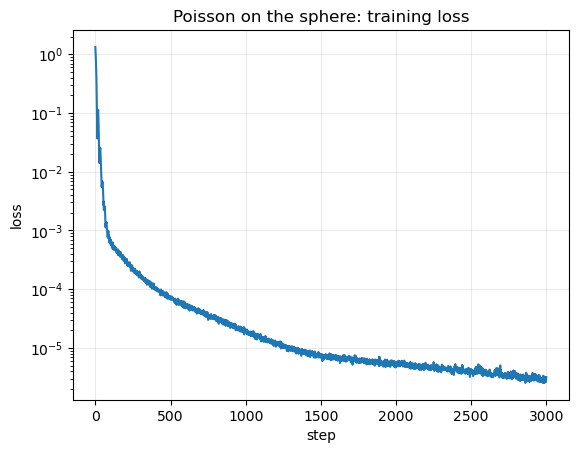

In [4]:
class SurfaceMLP(nn.Module):
    def __init__(self, hidden_dim: int = 64, hidden_layers: int = 3) -> None:
        super().__init__()
        layers = [nn.Linear(3, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 1)]
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


def sample_sphere(n_points: int) -> torch.Tensor: # uniform point on the unit sphere (normalize Gaussian sample)
    raw = torch.randn(n_points, 3)
    return (raw / raw.norm(dim=1, keepdim=True)).requires_grad_(True)


def f_sphere(x: torch.Tensor) -> torch.Tensor:
    return -2.0 * x[:, 2:3]

sphere_model = SurfaceMLP()
optimizer = torch.optim.Adam(sphere_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, factor=0.5)

sphere_history = []
N_STEPS = 3000
N_COLLOCATION = 512

for step in range(N_STEPS):
    x = sample_sphere(N_COLLOCATION)
    optimizer.zero_grad()
    residual = laplace_beltrami(sphere_model, x, normal_sphere) - f_sphere(x)
    loss = residual.square().mean()
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
    sphere_history.append(float(loss.detach()))
    if step % 200 == 0:
        print(f"step {step:5d}  loss {sphere_history[-1]:.3e}")

plt.semilogy(sphere_history)
plt.xlabel("step"); plt.ylabel("loss"); plt.title("Poisson on the sphere: training loss")
plt.grid(alpha=0.25)
plt.show()

In [5]:
@torch.no_grad()
def sphere_error(model, n_eval=4000):
    x = sample_sphere(n_eval).detach()
    prediction = model(x).squeeze(1)
    reference = x[:, 2]
    prediction = prediction - prediction.mean() # remove the undetermined additive constant
    reference = reference - reference.mean()
    return float((prediction - reference).norm() / reference.norm())

print("relative L2 error (mean removed):", sphere_error(sphere_model))

relative L2 error (mean removed): 0.0002083099097944796


### Visualizing the solution on the sphere

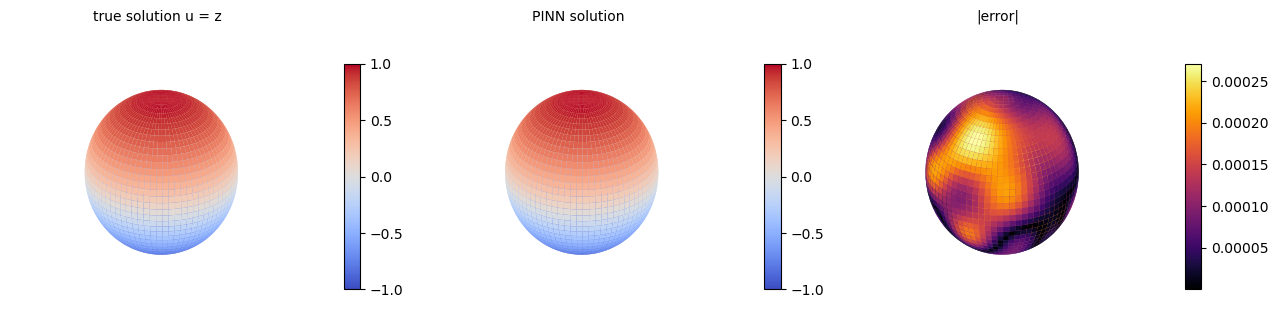

In [6]:
def sphere_grid(n_theta=80, n_phi=40):
    theta = torch.linspace(0, 2 * torch.pi, n_theta)
    phi = torch.linspace(1e-3, torch.pi - 1e-3, n_phi)
    TH, PH = torch.meshgrid(theta, phi, indexing="ij")
    X = torch.cos(TH) * torch.sin(PH)
    Y = torch.sin(TH) * torch.sin(PH)
    Z = torch.cos(PH)
    points = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    return X, Y, Z, points


def plot_surface_field(fig, ax, X, Y, Z, values, title="", cmap="coolwarm", vlims=None):
    values = values.reshape(X.shape)
    vmin, vmax = vlims if vlims is not None else (values.min(), values.max())
    norm = plt.Normalize(float(vmin), float(vmax))
    colors = plt.get_cmap(cmap)(norm(values.detach().numpy()))
    ax.plot_surface(X.numpy(), Y.numpy(), Z.numpy(), facecolors=colors,
                     rstride=1, cstride=1, linewidth=0, antialiased=True, shade=False)
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.1, aspect=14)


X, Y, Z, grid_points = sphere_grid()
with torch.no_grad():
    prediction_grid = sphere_model(grid_points).squeeze(1)
    prediction_grid = prediction_grid - prediction_grid.mean()  # remove the free constant
reference_grid = Z.flatten() - Z.flatten().mean()
error_grid = (prediction_grid - reference_grid).abs()

fig = plt.figure(figsize=(13, 4.4))
shared_lims = (min(prediction_grid.min(), reference_grid.min()),
               max(prediction_grid.max(), reference_grid.max()))
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
plot_surface_field(fig, ax1, X, Y, Z, reference_grid, "true solution u = z", vlims=shared_lims)
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
plot_surface_field(fig, ax2, X, Y, Z, prediction_grid, "PINN solution", vlims=shared_lims)
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
plot_surface_field(fig, ax3, X, Y, Z, error_grid, "|error|", cmap="inferno")
plt.tight_layout()
plt.show()

## 5. Poisson equation on the cylinder (a surface with a boundary)

**Surface.** The unit-radius cylinder $\Omega=\{(x,y,z): x^2+y^2=1,\ z\in[-L,L]\}$, parameterized by angle $\theta$ and height $z$: $\mathbf x(\theta,z)=(\cos\theta,\sin\theta,z)$. Its normal is just as simple as the sphere's: $\mathbf n(x,y,z) = (x,y,0)/\sqrt{x^2+y^2}$, the radial direction in the $xy$-plane.

**Why this example, after the sphere.** The cylinder is curved (it has nonzero mean curvature) yet, unrolled, it is intrinsically **flat** — its Gaussian curvature is zero. In $(\theta,z)$ coordinates, the metric is simply $ds^2=d\theta^2+dz^2$, so the Laplace–Beltrami operator reduces to the ordinary flat 2-D Laplacian: $\Delta_\Omega u = u_{\theta\theta}+u_{zz}$. That gives you a hand-checkable target and, unlike the sphere, a genuine **boundary** — the two end circles $z=\pm L$ — to practice a Dirichlet condition on.

**Problem.** Take $u(\theta,z)=z\cos\theta$, i.e. $u(x,y,z)=xz$ in ambient coordinates. Then $u_{\theta\theta}=-z\cos\theta=-u$ and $u_{zz}=0$, so $\Delta_\Omega u = -u$, giving $f=-u$. The boundary condition is $u=g$ on the two circles $z=\pm L$, with $g$ taken to be the same closed-form $u$ restricted to $z=\pm L$.

**Boundary enforcement.** We use the same **soft** penalty PINNsur itself uses (Notebook 02's *hard* constraint trick does not extend as cleanly here, because the boundary is now two disconnected circles rather than a single point — a good discussion question, see the checkpoint below):

$$
\mathcal L = \mathcal L_{\text{PDE}} + \lambda_{BC}\,\mathcal L_{BC}, \qquad
\mathcal L_{BC} = \big(u_\theta(\mathbf x) - g(\mathbf x)\big)^2 \ \text{ for } \mathbf x \text{ on } z=\pm L.
$$

In [7]:
CYLINDER_L = 1.5

def normal_cylinder(x: torch.Tensor) -> torch.Tensor: # unit vector
    radial = torch.stack([x[:, 0], x[:, 1], torch.zeros_like(x[:, 2])], dim=1)
    return radial / radial.norm(dim=1, keepdim=True)

def u_cylinder(x: torch.Tensor) -> torch.Tensor: # sol
    return (x[:, 0] * x[:, 2]).unsqueeze(1)   # x*z = cos(theta)*z

def f_cylinder(x: torch.Tensor) -> torch.Tensor: # sol
    return -u_cylinder(x)

def sample_cylinder_interior(n_points: int) -> torch.Tensor: # not sampling in [-L,L]
    theta = torch.rand(n_points) * 2 * torch.pi
    z = (torch.rand(n_points) * 2 - 1) * CYLINDER_L
    x = torch.stack([torch.cos(theta), torch.sin(theta), z], dim=1)
    return x.requires_grad_(True)

def sample_cylinder_boundary(n_points: int) -> torch.Tensor: # with mask almost half-half on each boundary
    theta = torch.rand(n_points) * 2 * torch.pi
    z = torch.where(torch.rand(n_points) < 0.5,
                     torch.full((n_points,), CYLINDER_L),
                     torch.full((n_points,), -CYLINDER_L))
    x = torch.stack([torch.cos(theta), torch.sin(theta), z], dim=1)
    return x.requires_grad_(True)


cylinder_model = SurfaceMLP()
optimizer = torch.optim.Adam(cylinder_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, factor=0.5)
LAMBDA_BC = 100.0

cylinder_history = {"pde": [], "boundary": []}
N_STEPS = 3000

for step in range(N_STEPS):
    x_interior = sample_cylinder_interior(512)
    x_boundary = sample_cylinder_boundary(128)

    optimizer.zero_grad()
    residual = laplace_beltrami(cylinder_model, x_interior, normal_cylinder) - f_cylinder(x_interior)
    pde_loss = residual.square().mean()
    boundary_loss = (cylinder_model(x_boundary) - u_cylinder(x_boundary)).square().mean()
    total_loss = pde_loss + LAMBDA_BC * boundary_loss

    total_loss.backward()
    optimizer.step()
    scheduler.step(total_loss)

    cylinder_history["pde"].append(float(pde_loss.detach()))
    cylinder_history["boundary"].append(float(boundary_loss.detach()))
    if step % 200 == 0:
        print(f"step {step:5d}  pde {pde_loss.item():.3e}  boundary {boundary_loss.item():.3e}")

step     0  pde 3.981e-01  boundary 1.100e+00
step   200  pde 3.485e-01  boundary 2.192e-04
step   400  pde 2.650e-01  boundary 1.067e-04
step   600  pde 1.989e-01  boundary 7.235e-05
step   800  pde 1.568e-01  boundary 3.721e-05
step  1000  pde 1.130e-01  boundary 6.590e-05
step  1200  pde 8.180e-02  boundary 7.281e-05
step  1400  pde 6.331e-02  boundary 1.631e-04
step  1600  pde 3.648e-02  boundary 2.925e-05
step  1800  pde 2.561e-02  boundary 1.050e-04
step  2000  pde 2.153e-02  boundary 1.839e-04
step  2200  pde 1.588e-02  boundary 2.130e-04
step  2400  pde 1.447e-02  boundary 4.904e-05
step  2600  pde 1.162e-02  boundary 2.066e-05
step  2800  pde 1.165e-02  boundary 1.066e-05


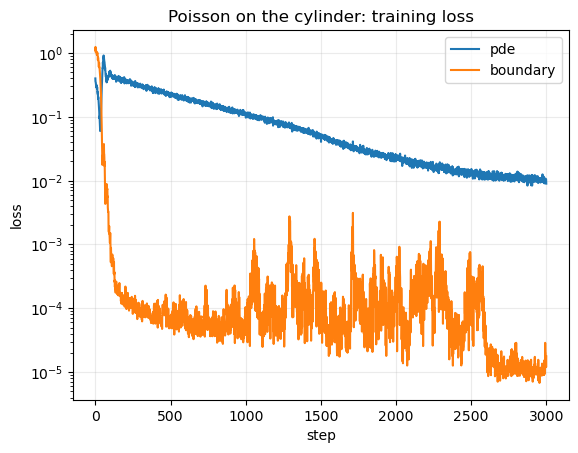

relative L2 error (interior): 0.012400859035551548


In [8]:
plt.semilogy(cylinder_history["pde"], label="pde")
plt.semilogy(cylinder_history["boundary"], label="boundary")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.25)
plt.title("Poisson on the cylinder: training loss")
plt.show()

@torch.no_grad()
def cylinder_error(model, n_eval=4000):
    x = sample_cylinder_interior(n_eval).detach()
    prediction = model(x).squeeze(1)
    reference = u_cylinder(x).squeeze(1)
    return float((prediction - reference).norm() / reference.norm())

print("relative L2 error (interior):", cylinder_error(cylinder_model))

### Visualizing the solution on the cylinder

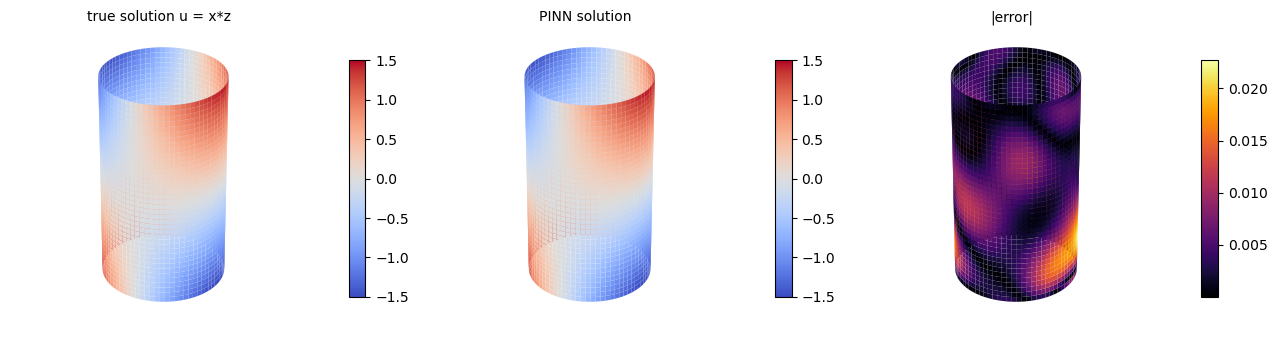

In [9]:
def cylinder_grid(n_theta=80, n_z=40):
    theta = torch.linspace(0, 2 * torch.pi, n_theta)
    z = torch.linspace(-CYLINDER_L, CYLINDER_L, n_z)
    TH, ZZ = torch.meshgrid(theta, z, indexing="ij")
    X = torch.cos(TH)
    Y = torch.sin(TH)
    points = torch.stack([X.flatten(), Y.flatten(), ZZ.flatten()], dim=1)
    return X, Y, ZZ, points

Xc, Yc, Zc, grid_points_c = cylinder_grid()
with torch.no_grad():
    prediction_grid_c = cylinder_model(grid_points_c).squeeze(1)
reference_grid_c = grid_points_c[:, 0] * grid_points_c[:, 2]  # x*z
error_grid_c = (prediction_grid_c - reference_grid_c).abs()

fig = plt.figure(figsize=(13, 4.6))
shared_lims_c = (min(prediction_grid_c.min(), reference_grid_c.min()),
                 max(prediction_grid_c.max(), reference_grid_c.max()))
for i, (values, title, cmap, lims) in enumerate([
    (reference_grid_c, "true solution u = x*z", "coolwarm", shared_lims_c),
    (prediction_grid_c, "PINN solution", "coolwarm", shared_lims_c),
    (error_grid_c, "|error|", "inferno", None),
]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    plot_surface_field(fig, ax, Xc, Yc, Zc, values, title, cmap=cmap, vlims=lims)
    ax.set_box_aspect([1, 1, 1.6])
plt.tight_layout()
plt.show()

## 6. Stretch: when you don't know the normal in closed form

Every example so far used a normal field you could write down by hand. Real meshes don't hand you that — PINNsur's actual contribution (Section 3.4 of the paper) is training a small **normal network** $\mathbf n_{\hat\theta}:\mathbb R^3\to\mathbb R^3$ to approximate the surface normal, using ground-truth normals computed from mesh faces (cross products of edges) or, in our case, the analytic normal we already have — which doubles as a way to check the learned version against a known-correct answer before trusting it on a surface where you have no ground truth at all.

**Loss (paper's Equation 13).** Only the *direction* matters, so the loss is a cosine penalty, not a squared error:

$$
\mathcal L_{\text{normals}} = \sum_i \big(1 - \mathbf n_{\hat\theta}(\mathbf x_i)\cdot \mathbf n_{\text{GT}}(\mathbf x_i)\big)^2 .
$$

In [10]:
class NormalNet(nn.Module): # small mlp for predicting a unit normal

    def __init__(self, hidden_dim: int = 64, hidden_layers: int = 3) -> None:
        super().__init__()
        layers = [nn.Linear(3, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 3)]
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        raw = self.network(x)
        return raw / raw.norm(dim=1, keepdim=True)

def sample_sphere_plain(n_points: int) -> torch.Tensor: # ground truth normals
    raw = torch.randn(n_points, 3)
    return raw / raw.norm(dim=1, keepdim=True)

normal_net = NormalNet()
normal_optimizer = torch.optim.Adam(normal_net.parameters(), lr=1e-3)

for step in range(1500):
    x = sample_sphere_plain(512)
    n_gt = x.clone()  # true normal of the unit sphere is the position itself
    normal_optimizer.zero_grad()
    n_pred = normal_net(x)
    loss = (1.0 - (n_pred * n_gt).sum(dim=1)).square().mean()
    loss.backward()
    normal_optimizer.step()
    if step % 300 == 0:
        print(f"step {step:5d}  normal loss {loss.item():.3e}")

for p in normal_net.parameters(): # normal net is pretrained, not part off PDE net's optimization
    p.requires_grad_(False)

def normal_net_fn(x): 
    # NOTE: no torch.no_grad() here -- normal_net's parameters are frozen
    # above, but laplace_beltrami still needs to differentiate this output
    # with respect to x itself to build the Jacobian. Wrapping the call in
    # torch.no_grad() would detach that graph and silently zero out the
    # normal field's contribution to every derivative below.
    return normal_net(x)

# re-solve the same problem; swapping only the normal field
sphere_model_learned = SurfaceMLP()
optimizer2 = torch.optim.Adam(sphere_model_learned.parameters(), lr=1e-3)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer2, patience=200, factor=0.5)

for step in range(3000):
    x = sample_sphere(512)
    optimizer2.zero_grad()
    residual = laplace_beltrami(sphere_model_learned, x, normal_net_fn) - f_sphere(x)
    loss = residual.square().mean()
    loss.backward()
    optimizer2.step()
    scheduler2.step(loss)

print("relative L2 error, analytic normal:", sphere_error(sphere_model))
print("relative L2 error, learned normal :", sphere_error(sphere_model_learned))

step     0  normal loss 1.543e+00
step   300  normal loss 7.780e-06
step   600  normal loss 1.417e-06
step   900  normal loss 6.007e-07
step  1200  normal loss 2.823e-07
relative L2 error, analytic normal: 0.00020496835350058973
relative L2 error, learned normal : 0.005430626217275858


### Visualizing analytic vs. learned normals

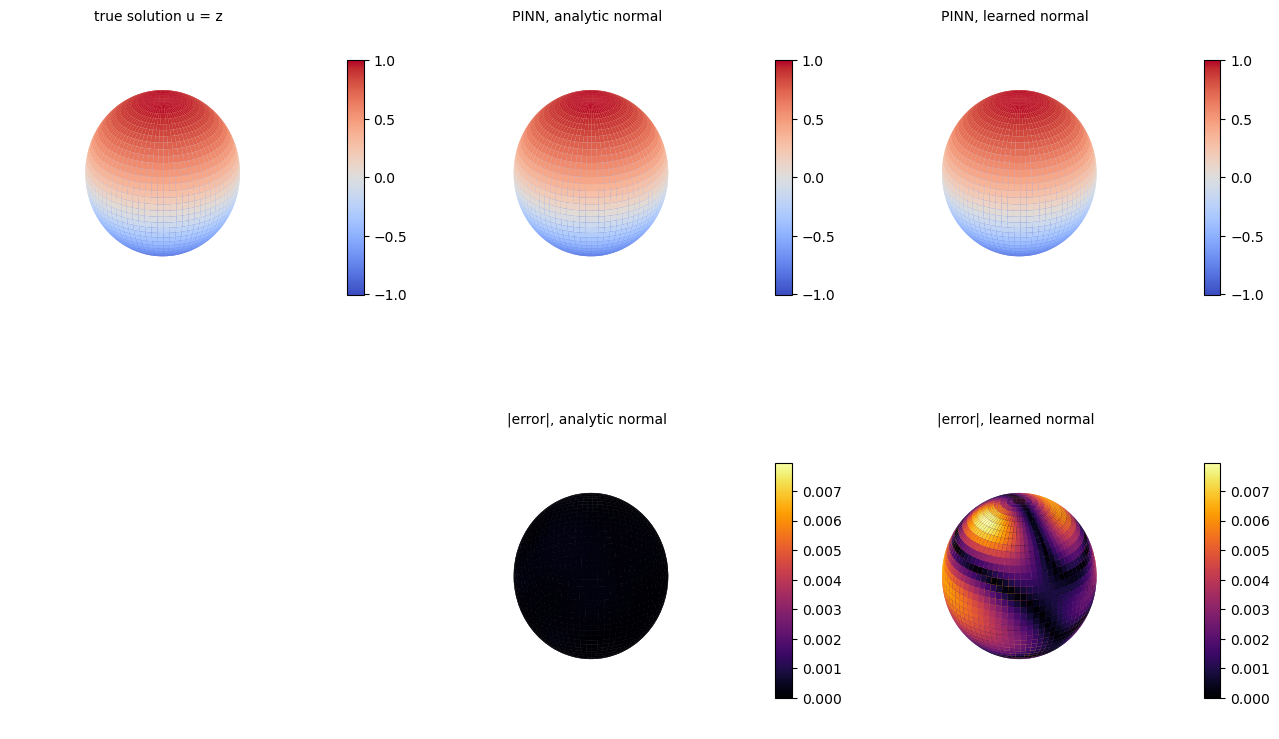

max |error|, analytic normal: 2.7066e-04
max |error|, learned normal : 7.9495e-03


In [11]:
with torch.no_grad():
    prediction_grid_learned = sphere_model_learned(grid_points).squeeze(1)
    prediction_grid_learned = prediction_grid_learned - prediction_grid_learned.mean()

# pointwise |error| against the true field, for both normal fields
error_grid_analytic = (prediction_grid - reference_grid).abs()
error_grid_learned = (prediction_grid_learned - reference_grid).abs()

fig = plt.figure(figsize=(13, 8.6))
shared_lims_stretch = ( # panels share one color scale, so we can compare them; avodiing auto-normalization!
    min(reference_grid.min(), prediction_grid.min(), prediction_grid_learned.min()),
    max(reference_grid.max(), prediction_grid.max(), prediction_grid_learned.max()),
)
shared_error_lims = (0.0, max(error_grid_analytic.max(), error_grid_learned.max()))

for i, (values, title) in enumerate([
    (reference_grid, "true solution u = z"),
    (prediction_grid, "PINN, analytic normal"),
    (prediction_grid_learned, "PINN, learned normal"),
]):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    plot_surface_field(fig, ax, X, Y, Z, values, title, vlims=shared_lims_stretch)

ax_err_analytic = fig.add_subplot(2, 3, 5, projection="3d")
plot_surface_field(fig, ax_err_analytic, X, Y, Z, error_grid_analytic,
                    "|error|, analytic normal", cmap="inferno", vlims=shared_error_lims)
ax_err_learned = fig.add_subplot(2, 3, 6, projection="3d")
plot_surface_field(fig, ax_err_learned, X, Y, Z, error_grid_learned,
                    "|error|, learned normal", cmap="inferno", vlims=shared_error_lims)

plt.tight_layout()
plt.show()

print(f"max |error|, analytic normal: {error_grid_analytic.max().item():.4e}")
print(f"max |error|, learned normal : {error_grid_learned.max().item():.4e}")


## 7. Wrap-up and further reading

The entire method fits in one idea, applied twice: project the ordinary Euclidean gradient onto the tangent plane to get $\nabla_\Omega$, and repeat the same projection on divergence to get $\Delta_\Omega$. Everything else — the coordinate network, the training loop, the loss, soft vs. hard boundary handling — is exactly the same as before.

**Where this goes if you keep pulling the thread** (not required for the lab, just pointers):

- **Higher-order geometry.** The paper also derives the **Helmholtz equation** ($\Delta_\Omega u + k^2 u = f$) the same way — literally one extra term in the residual — and shows the *same* Laplace–Beltrami building block solves the **heat equation** via an implicit time-step (a "screened Poisson" equation solved once per step), and even **mean curvature flow**: since $\Delta_\Omega\mathbf x = -2H\mathbf n$ relates the Laplace–Beltrami operator applied to a surface's own coordinates to its mean curvature $H$, solving three screened-Poisson problems (one per coordinate $x,y,z$) and feeding the result back in as new vertex positions makes the surface visibly relax toward a minimal surface over repeated steps — a genuinely striking demo if you want to build it later, but it stacks a time-stepping scheme on top of everything here and is intentionally out of scope today.
- **Arbitrary topology, arbitrary meshes.** Because this method only ever needs *a* differentiable normal field, it works unchanged on any orientable manifold — unlike the parametric approach of Williamson & Mitra (2025), which maps a sphere onto the surface and therefore cannot handle a surface with holes or handles.
- **Failure modes worth knowing about.** The paper reports the method struggles where the normal field is *discontinuous* (sharp corners) and where the target solution is high-frequency relative to the network — the same spectral-bias story from Notebook 04, just restated on a curved domain. Their fix for the second issue is a `Siren` (sine-activation) network in place of `tanh`; we used `tanh` throughout because every target here is deliberately low-frequency.

**Reference.** P. Jain, N. Kairanda, P. Y. Chen, O. Stein. *PINNsur: Physics-Informed Neural Networks for PDEs on Curved Surfaces.* Preprint, 2026. [arXiv:2605.27308](https://arxiv.org/abs/2605.27308).